# 04. Classification & Forecasting Models

## Superstore Sales Data Mining Project

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sys
sys.path.append('..')

from src.data.loader import DataLoader
from src.data.cleaner import DataCleaner
from src.features.builder import FeatureBuilder
from src.mining.clustering import ClusterMiner
from src.models.supervised import SupervisedModel
from src.models.forecasting import TimeSeriesModel
from sklearn.preprocessing import StandardScaler

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 8)

## 1. Classification: Predict Customer Segment

In [2]:
# Load data and create features
loader = DataLoader()
df = loader.generate_sample_data(n_orders=2000)

cleaner = DataCleaner(df)
df = cleaner.handle_missing_values()

builder = FeatureBuilder(df)
rfm = builder.create_rfm_features()

# Cluster for labels
feature_cols = ['Recency', 'Frequency', 'Monetary']
scaler = StandardScaler()
features_scaled = scaler.fit_transform(rfm[feature_cols])

clusterer = ClusterMiner(n_clusters=4, random_state=42)
labels = clusterer.fit_kmeans(features_scaled, n_clusters=4)

rfm['Cluster'] = labels
rfm['Segment'] = rfm['Cluster'].map({0: 'Segment A', 1: 'Segment B', 2: 'Segment C', 3: 'Segment D'})

# Create features for classification
rfm['Avg_Profit'] = rfm['Total_Profit'] / rfm['Frequency']
rfm['Avg_Order_Value'] = rfm['Monetary'] / rfm['Frequency']
rfm['Profit_Margin'] = rfm['Total_Profit'] / rfm['Monetary']

X = rfm[['Recency', 'Frequency', 'Monetary', 'Total_Profit', 'Avg_Profit', 'Avg_Order_Value', 'Profit_Margin']]
y = rfm['Segment']

print(f"Features shape: {X.shape}")
print(f"Classes: {y.unique()}")

INFO:src.data.loader:Generated 6986 sample records
INFO:src.data.cleaner:Handling missing values...
INFO:src.features.builder:Creating RFM features...
INFO:src.features.builder:Created RFM features for 849 customers
INFO:src.features.builder:Segment distribution:
Segment
Loyal Customers        283
New Customers          200
Potential Loyalists    110
Lost                    84
At Risk                 59
Champions               57
Promising               56
Name: count, dtype: int64
INFO:src.mining.clustering:Fitting K-Means with 4 clusters...
INFO:src.mining.clustering:K-Means clustering complete. Silhouette: 0.3837


Features shape: (849, 7)
Classes: ['Segment B' 'Segment C' 'Segment D' 'Segment A']


In [3]:
# Train classification models
clf = SupervisedModel(random_state=42, test_size=0.2)
clf.prepare_data(X, y, scale=True)

# Baseline 1: Logistic Regression
clf.train_baseline_logistic_regression()

# Baseline 2: Decision Tree
clf.train_baseline_decision_tree(max_depth=10)

# Improved: Random Forest
clf.train_improved_random_forest(n_estimators=100, max_depth=15)

INFO:src.models.supervised:Preparing data for modeling...
INFO:src.models.supervised:Train size: 679, Test size: 170
INFO:src.models.supervised:Classes: ['Segment A' 'Segment B' 'Segment C' 'Segment D']
INFO:src.models.supervised:Training Logistic Regression...
INFO:src.models.supervised:Logistic Regression - F1 Macro: 0.9550
INFO:src.models.supervised:Training Decision Tree (max_depth=10)...
INFO:src.models.supervised:Decision Tree - F1 Macro: 0.9602
INFO:src.models.supervised:Training Random Forest (n_estimators=100)...
INFO:src.models.supervised:Random Forest - F1 Macro: 0.9641


{'model': RandomForestClassifier(max_depth=15, min_samples_leaf=2, min_samples_split=5,
                        n_jobs=-1, random_state=42),
 'metrics': {'accuracy': 0.9705882352941176,
  'precision_macro': np.float64(0.9764239028944911),
  'recall_macro': np.float64(0.9547803617571059),
  'f1_macro': np.float64(0.9640538914360925),
  'f1_weighted': np.float64(0.9704270132716444),
  'roc_auc': np.float64(0.9994761745979722),
  'confusion_matrix': [[16, 2, 0, 0],
   [0, 47, 0, 0],
   [0, 2, 40, 1],
   [0, 0, 0, 62]],
  'cv_f1_mean': np.float64(0.969942165067487),
  'cv_f1_std': np.float64(0.007067735899935028)}}

In [4]:
# Model comparison
print("\n=== Classification Model Comparison ===")
comparison = clf.compare_models()
print(comparison)


=== Classification Model Comparison ===
                Model  accuracy  precision_macro  recall_macro  f1_macro  \
2        RandomForest  0.970588         0.976424      0.954780  0.964054   
1        DecisionTree  0.970588         0.966020      0.955275  0.960202   
0  LogisticRegression  0.964706         0.973155      0.941386  0.954998   

   f1_weighted   roc_auc  cv_f1_mean  cv_f1_std  
2     0.970427  0.999476    0.969942   0.007068  
1     0.970465  0.979726    0.965045   0.004921  
0     0.964217  0.998587    0.973875   0.007140  



Feature Importance (Random Forest):
           Feature  Importance
0          Recency    0.349315
1        Frequency    0.253970
2         Monetary    0.227598
3     Total_Profit    0.081088
5  Avg_Order_Value    0.037996
6    Profit_Margin    0.025616
4       Avg_Profit    0.024416


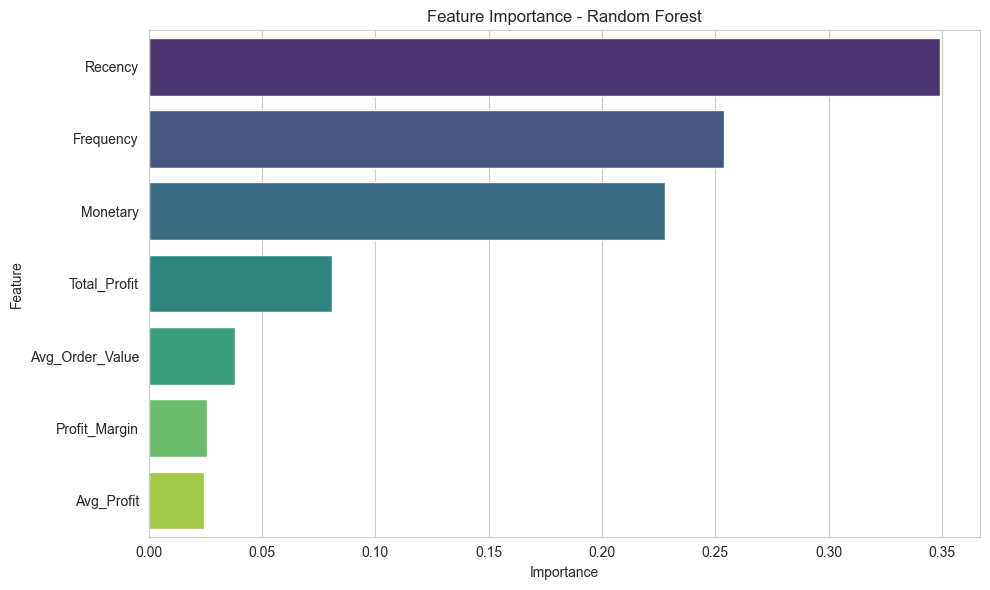

Saved: outputs/figures/10_feature_importance.png


In [5]:
# Feature importance (Random Forest)
print("\nFeature Importance (Random Forest):")
importance = clf.get_feature_importance('RandomForest')
print(importance)

# Plot feature importance
fig, ax = plt.subplots(figsize=(10, 6))
sns.barplot(data=importance, x='Importance', y='Feature', palette='viridis', ax=ax)
ax.set_title('Feature Importance - Random Forest')
plt.tight_layout()
plt.savefig('../outputs/figures/10_feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: outputs/figures/10_feature_importance.png")

In [6]:
# Confusion matrix for best model
best_model = comparison.iloc[0]['Model']
clf.plot_confusion_matrix(best_model, save_path='../outputs/figures/11_confusion_matrix.png')
print(f"Saved: outputs/figures/11_confusion_matrix.png")

Saved: outputs/figures/11_confusion_matrix.png


## 2. Forecasting: Sales Prediction

In [7]:
# Prepare time series
df['Order Date'] = pd.to_datetime(df['Order Date'])

ts_model = TimeSeriesModel(freq='W', test_size=0.2)
ts = ts_model.prepare_time_series(df, 'Order Date', 'Sales', 'sum')
train, test = ts_model.train_test_split(n_test=12)

print(f"Train: {len(train)}, Test: {len(test)}")

INFO:src.models.forecasting:Preparing time series: Sales by Order Date
INFO:src.models.forecasting:Time series shape: 849 periods
INFO:src.models.forecasting:Train: 837, Test: 12


Train: 837, Test: 12


In [8]:
# Baselines
ts_model.baseline_naive()
ts_model.baseline_moving_average(window=4)

# Models
ts_model.fit_arima(order=(1, 1, 1))
ts_model.fit_holt_winters(seasonal='add', seasonal_periods=12)

INFO:src.models.forecasting:Running Naive baseline...
INFO:src.models.forecasting:Naive - MAE: 2491.04, RMSE: 2823.70
INFO:src.models.forecasting:Running Moving Average (window=4)...
INFO:src.models.forecasting:MA-4 - MAE: 1938.75, RMSE: 2822.32
INFO:src.models.forecasting:Fitting ARIMA(1, 1, 1)...
C:\Users\Liketech\AppData\Roaming\Python\Python312\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
C:\Users\Liketech\AppData\Roaming\Python\Python312\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
C:\Users\Liketech\AppData\Roaming\Python\Python312\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, 

{'model': <statsmodels.tsa.holtwinters.results.HoltWintersResultsWrapper at 0x20c06babc80>,
 'predictions': array([3657.85199058, 4212.61329137, 3903.19078405, 4241.45826355,
        4229.97383077, 4193.81852861, 4046.99879705, 4307.90453841,
        4650.98418201, 5400.93220767, 4174.1501519 , 4195.97038661]),
 'metrics': {'mae': np.float64(2284.8472093075943),
  'rmse': np.float64(2500.4789297026387),
  'smape': np.float64(65.31589851624891),
  'mape': np.float64(3048209992216.058)}}

In [9]:
# Forecasting comparison
print("\n=== Forecasting Model Comparison ===")
ts_comparison = ts_model.compare_models()
print(ts_comparison)


=== Forecasting Model Comparison ===
         Model          mae         rmse      smape          mape
1         MA_4  1938.745000  2822.319745  55.659806  2.569283e+12
3  HoltWinters  2284.847209  2500.478930  65.315899  3.048210e+12
2        ARIMA  2488.557925  2822.755163  68.405104  3.485831e+12
0        Naive  2491.035000  2823.700302  68.451152  3.489767e+12


In [10]:
# Plot forecast
ts_model.plot_forecast(save_path='../outputs/figures/12_forecast.png')
print("Saved: outputs/figures/12_forecast.png")

INFO:src.models.forecasting:Forecast plot saved to ../outputs/figures/12_forecast.png


Saved: outputs/figures/12_forecast.png


## 3. Save Results

In [11]:
# Save model results
comparison.to_csv('../outputs/tables/04_classification_comparison.csv', index=False)
ts_comparison.to_csv('../outputs/tables/04_forecasting_comparison.csv', index=False)
importance.to_csv('../outputs/tables/04_feature_importance.csv', index=False)

print("Modeling completed!")
print("Saved:")
print("  - outputs/tables/04_classification_comparison.csv")
print("  - outputs/tables/04_forecasting_comparison.csv")
print("  - outputs/tables/04_feature_importance.csv")

Modeling completed!
Saved:
  - outputs/tables/04_classification_comparison.csv
  - outputs/tables/04_forecasting_comparison.csv
  - outputs/tables/04_feature_importance.csv
